<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Комментарий ревьюера</b>


Привет, Никита! Давай знакомиться! Меня зовут Дмитрий Махортов, и я буду проверять твой проект. Сразу предлагаю общение на «ты» 🙂, но если тебе это не комфортно, то дай знать, и мы перейдем на «вы». 


Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе погрузиться в увлекательный мир работы с данными и вырасти в крепкого профи. Это отдаленная цель. А ближайшая - сделать твою работу еще лучше )).
   
    
Все ключевые этапы в работе выполнены, и я вижу что с проектом ты справшяешься. Есть моменты, которые нужно доработать, но я уверен, у тебя все получится.
        
Расскажу как обычно проходит проверка:    
Бывают моменты, которые требуют пристального внимания. Комментарии по ним выделены <span style='background-color:#F7B3A4'> красным цветом </span> и обозначены значком 🛑. После их доработки проект будет принят.  🙂
 
<span style='background-color:#B7EBA7'> Зеленым цветом </span> и значком ✅ отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. Или советы «со звездочкой», которые помогут тебе в будущем.

<span style='background-color:#F9EDA6'>Жёлтым цветом </span> и значком ⚠️ выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее. 
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Привет! Можно на ты.

</div>

# Поиск изображений по текстовому описанию

## Proof of Concept для фотохостинга «Со Смыслом»

**Цель:** построить модель, которая по конкатенации признаков изображения и текста оценивает их соответствие числом от 0 до 1, а затем применить её для поиска изображения по запросу.

План работы:

1. загрузить и исследовать данные и разметку;
2. удалить пары с упоминаниями лиц младше 16 лет;
3. получить семантические признаки текста с помощью MiniLM, изображения — с помощью предобученной ResNet50;
4. сравнить линейную регрессию и полносвязные нейронные сети;
5. проверить лучшую модель как регрессор и как поисковый ранжировщик;
6. реализовать функцию демонстрационного поиска с юридическим дисклеймером.

В проекте используется один фреймворк глубокого обучения — **PyTorch**. Scikit-learn применяется только для классической регрессии, подготовки признаков и метрик.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Да, это хорошая практика - дать описание контекста и проблемы, которую мы решаем. </div>

## 1. Загрузка и исследование данных

Импорты, константы и фиксация случайности. Если ноутбук запускается не из корня проекта, достаточно изменить `DATA_DIR`.

In [1]:
from collections import Counter
from copy import deepcopy
from pathlib import Path
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import Normalizer
from sentence_transformers import SentenceTransformer

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet50_Weights, resnet50

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
DATA_DIR = Path("dataset")
TRAIN_IMAGE_DIR = DATA_DIR / "train_images"
TEST_IMAGE_DIR = DATA_DIR / "test_images"
CACHE_DIR = DATA_DIR / "embeddings_cache"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Устройство:", DEVICE)

Устройство: cuda


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Да, это хорошая практика - дать описание контекста и проблемы, которую мы решаем. </div>

In [2]:
train_pairs = pd.read_csv(DATA_DIR / "train_dataset.csv")
expert = pd.read_csv(
    DATA_DIR / "ExpertAnnotations.tsv",
    sep="\t",
    header=None,
    names=["image", "query_id", "expert_1", "expert_2", "expert_3"],
)
crowd = pd.read_csv(
    DATA_DIR / "CrowdAnnotations.tsv",
    sep="\t",
    header=None,
    names=["image", "query_id", "agreement", "yes", "no"],
)
test_queries = pd.read_csv(DATA_DIR / "test_queries.csv", sep="|", index_col=0)
test_images = pd.read_csv(DATA_DIR / "test_images.csv")

tables = {
    "train_pairs": train_pairs,
    "expert": expert,
    "crowd": crowd,
    "test_queries": test_queries,
    "test_images": test_images,
}
for name, frame in tables.items():
    print(f"{name:13}: {frame.shape}, пропусков: {frame.isna().sum().sum()}, дубликатов: {frame.duplicated().sum()}")

display(train_pairs.head(3), expert.head(3), crowd.head(3), test_queries.head(3))

train_pairs  : (5822, 3), пропусков: 0, дубликатов: 0
expert       : (5822, 5), пропусков: 0, дубликатов: 0
crowd        : (47830, 5), пропусков: 0, дубликатов: 0
test_queries : (500, 3), пропусков: 0, дубликатов: 0
test_images  : (100, 1), пропусков: 0, дубликатов: 0


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


,image,query_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2


,image,query_id,agreement,yes,no
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg


`train_dataset.csv` и экспертная разметка должны соединяться по паре `(image, query_id)`. Проверим ключи, диапазоны оценок, существование файлов и базовую структуру текстов.

In [3]:
assert set(train_pairs.columns) == {"image", "query_id", "query_text"}
assert not train_pairs.duplicated(["image", "query_id"]).any()
assert not expert.duplicated(["image", "query_id"]).any()
assert expert[["expert_1", "expert_2", "expert_3"]].stack().between(1, 4).all()

data = train_pairs.merge(expert, on=["image", "query_id"], how="inner", validate="one_to_one")
assert len(data) == len(train_pairs), "Не всем обучающим парам найдена экспертная оценка"

data["expert_mean"] = data[["expert_1", "expert_2", "expert_3"]].mean(axis=1)
# Шкала 1..4 линейно переводится в требуемый диапазон 0..1.
data["target"] = (data["expert_mean"] - 1) / 3

missing_train_images = [name for name in data["image"].unique() if not (TRAIN_IMAGE_DIR / name).is_file()]
missing_test_images = [name for name in test_images["image"] if not (TEST_IMAGE_DIR / name).is_file()]

print(f"Пар: {len(data):,}")
print(f"Уникальных изображений: {data['image'].nunique():,}")
print(f"Уникальных запросов: {data['query_id'].nunique():,}")
print(f"Описаний на изображение (медиана): {data.groupby('image').size().median():.0f}")
print(f"Отсутствующих train/test-файлов: {len(missing_train_images)}/{len(missing_test_images)}")
display(data.describe(include="all").T)

Пар: 5,822
Уникальных изображений: 1,000
Уникальных запросов: 977
Описаний на изображение (медиана): 6
Отсутствующих train/test-файлов: 0/0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image,5822,1000,1339596997_8ac29c1841.jpg,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_id,5822,977,2600867924_cd502fc911.jpg#2,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_text,5822,977,"Two dogs , one brown and white and one black a...",34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expert_1,5822.0,NaN,NaN,NaN,1.43662,0.787084,1.0,1.0,1.0,2.0,4.0
expert_2,5822.0,NaN,NaN,NaN,1.624356,0.856222,1.0,1.0,1.0,2.0,4.0
expert_3,5822.0,NaN,NaN,NaN,1.881999,0.904087,1.0,1.0,2.0,2.0,4.0
expert_mean,5822.0,NaN,NaN,NaN,1.647658,0.806205,1.0,1.0,1.333333,2.0,4.0
target,5822.0,NaN,NaN,NaN,0.215886,0.268735,0.0,0.0,0.111111,0.333333,1.0


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

По объединению экспертных и крауд оценок все ОК, но подсвечу возможные альтернативы
    
--------------    
    
    
В этом проекте есть несколько возможных стратегий работы с обучающими и краудсорс оценками,  вот эти стратегии с плюсами и минусами:
   

   - использовать соединение через outer, в этом случае, при корректной обработке пропусков мы можем получить более 50К размеченых пар. К плюсам данного подхода можно отнести большое количество данных. Минус - в основном это будут данные, размеченные краудсорсерами, а там качество раметки ниже.
   - использовать только экспертные оценки. плюс - высокое качество данных (разметка имеет шкалу). Минус - данных меньше.  Поясню по поводу качества разметки на примере: если на изображении одна собака, а в описании "две собаки бегут по берегу", то эксперты поставять соответствие 0,6-0,7 (переводя в шкалу 0-1), а краудсорсеры поставят 0.  Но на экспертных оценках модель хотя-бы научится находить собак, а на краудсор оценках ничему не начится.

   - использование соединения через left.  Данный подход очевидно проигрывает второму варианту: данных столько же, нужно дополнительно возиться с объединением, но качество разметки снижается.. Но это соответсвует предложениям авторов проекта, поэтому такой подход имеет право на жизнь

   - объединение через inner. Тут все плохо - и данных ОЧЕНЬ мало (в два раза меньше, чем использовать только экспертные оценки) и качество у них "подпорчено". И навыков по обработке пропусков не получаем.....


</div>

Доля полного согласия экспертов: 0.582
Среднее стандартное отклонение: 0.254


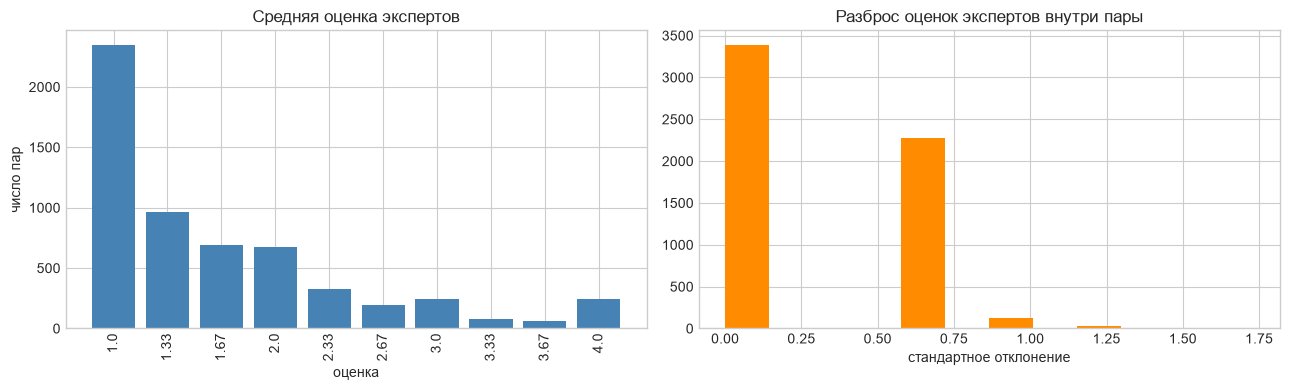

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
score_counts = data["expert_mean"].round(2).value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values, color="steelblue")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set(title="Средняя оценка экспертов", xlabel="оценка", ylabel="число пар")

expert_std = data[["expert_1", "expert_2", "expert_3"]].std(axis=1)
axes[1].hist(expert_std, bins=12, color="darkorange")
axes[1].set(title="Разброс оценок экспертов внутри пары", xlabel="стандартное отклонение")
plt.tight_layout()

print("Доля полного согласия экспертов:", round((expert_std == 0).mean(), 3))
print("Среднее стандартное отклонение:", round(expert_std.mean(), 3))


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Если формально - элементы EDA в твоем проекте есть. Однако давай не будем забывать, что проект мультимодальный и кроме оценок (распределение которых безуслоно нужно исследовать) важно также посмотрить и на изображения и на тексты.
    
На изображения важно как минимум посмотреть глазами, убедиться что все они присутствуют физически на диске, проверить пропорции, ведь перед подачей в нейронку они будут приводиться к квадратному виду и при этом могут измениться пропорции изображений, если выбрать неподходящий метод сжатия.
    
А что касается текстов, то было бы неплохо посмотреть какие самые частотные слова, можно оценить длинну, понять сколько всего уникальных описаний мы имеем.
    
Также было бы неплохо собрать всё вместе - посмотреть на пары изображение + описание для высоких и низких оценок.    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Спасибо! Я дополнил EDA: проверил размеры и пропорции файлов, посмотрел случайные изображения, исследовал длины текстов и частотные слова, а также вывел пары с низкими и высокими оценками.

</div>

Файлов изображений проверено: 1000
Уникальных описаний: 977
Медианная длина описания: 10 слов


,count,mean,std,min,25%,50%,75%,max
width,1000.0,455.91300,69.787346,200.0,379.50,500.000000,500.000000,500.000000
height,1000.0,398.28300,75.079170,166.0,333.00,375.000000,500.000000,500.000000
aspect_ratio,1000.0,1.21068,0.358629,0.4,0.76,1.333333,1.501502,3.012048


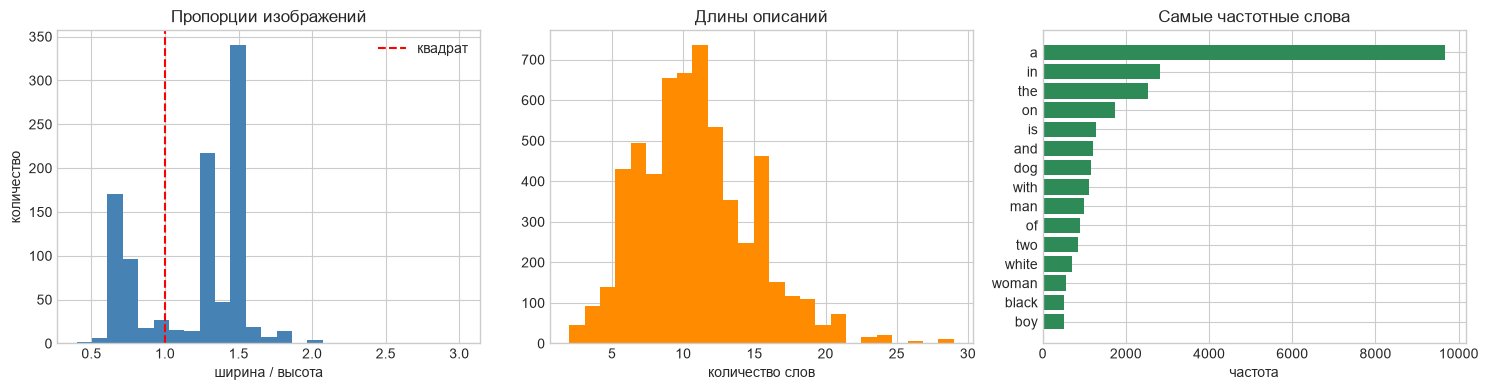

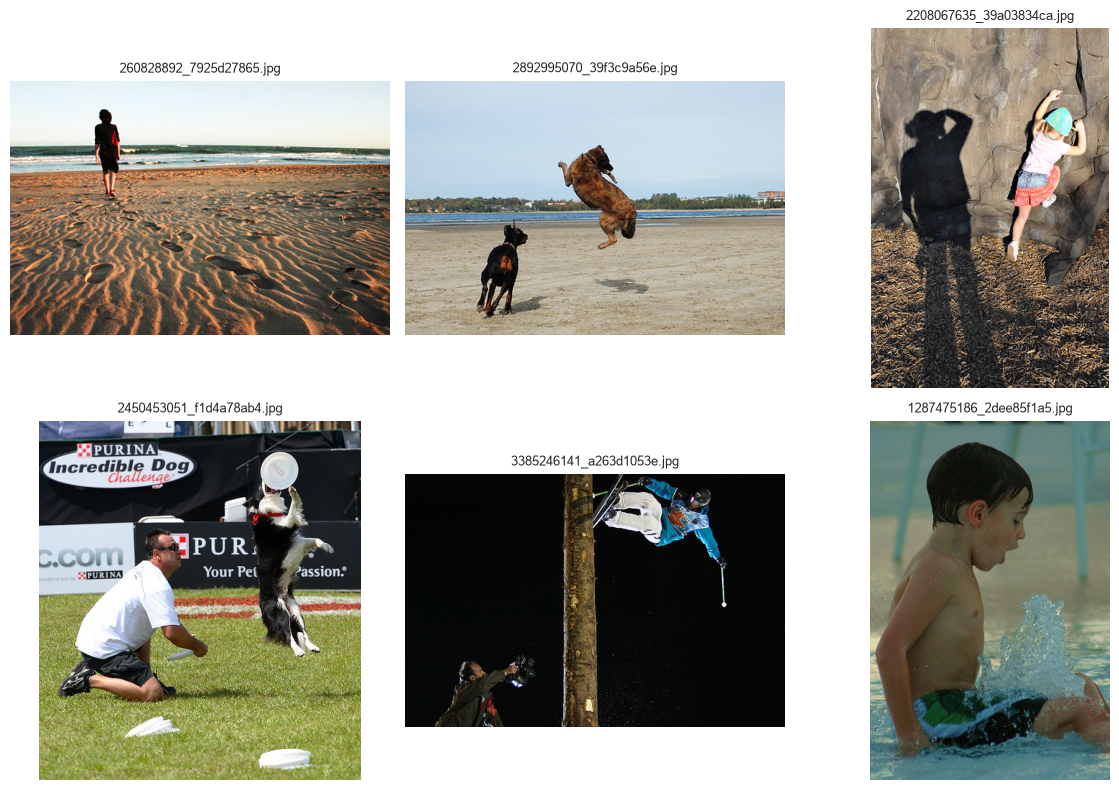

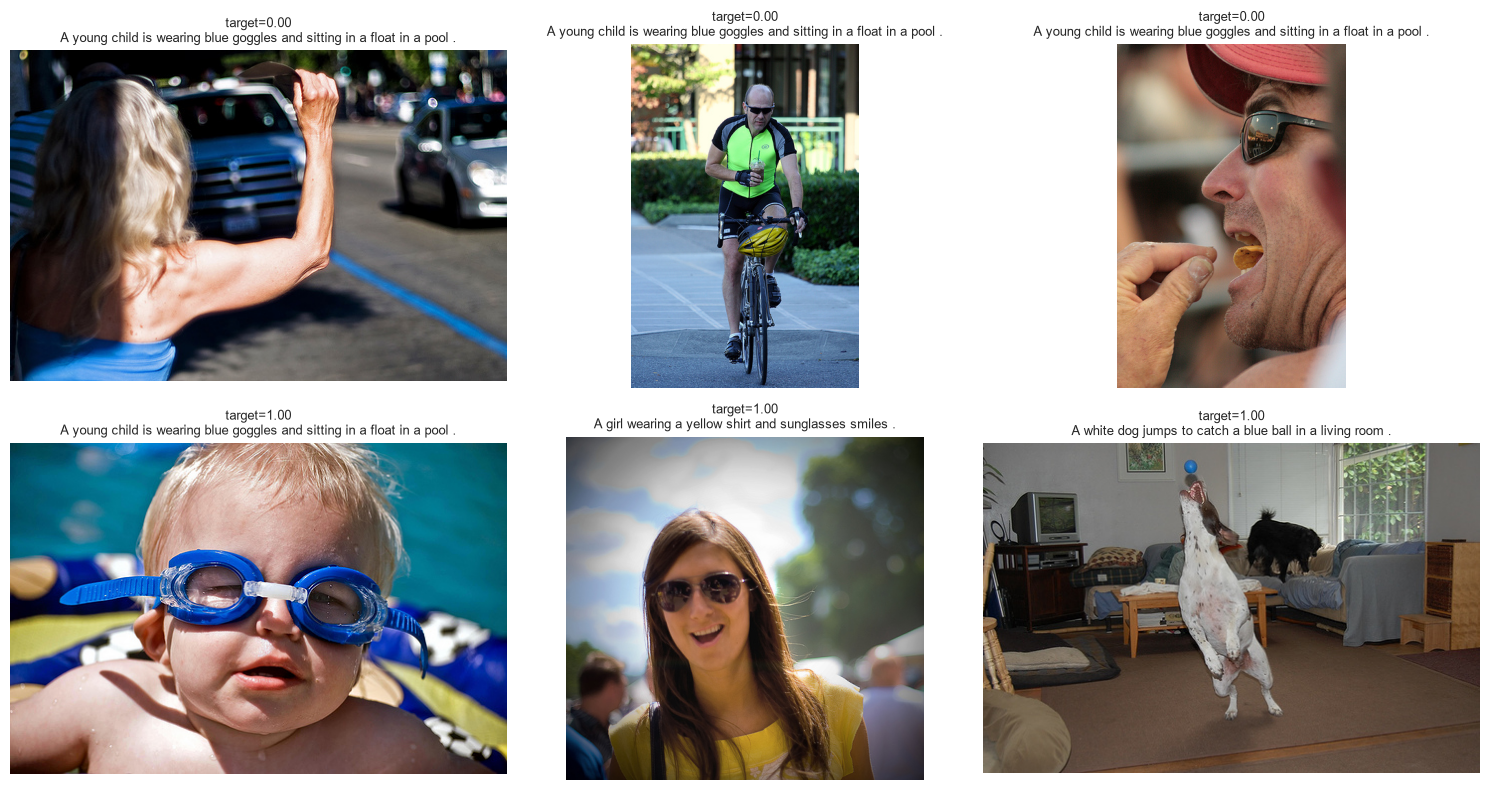

In [5]:
image_stats = []
for image_name in data["image"].drop_duplicates():
    image_path = TRAIN_IMAGE_DIR / image_name
    with Image.open(image_path) as image:
        width, height = image.size
    image_stats.append({
        "image": image_name,
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
    })
image_stats = pd.DataFrame(image_stats)

tokenized_texts = data["query_text"].str.lower().str.findall(r"[a-z']+")
text_lengths = tokenized_texts.str.len()
word_counts = Counter(word for words in tokenized_texts for word in words)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(image_stats["aspect_ratio"], bins=25, color="steelblue")
axes[0].axvline(1, color="red", linestyle="--", label="квадрат")
axes[0].set(title="Пропорции изображений", xlabel="ширина / высота", ylabel="количество")
axes[0].legend()
axes[1].hist(text_lengths, bins=25, color="darkorange")
axes[1].set(title="Длины описаний", xlabel="количество слов")
common_words = pd.Series(dict(word_counts.most_common(15)))
axes[2].barh(common_words.index[::-1], common_words.values[::-1], color="seagreen")
axes[2].set(title="Самые частотные слова", xlabel="частота")
plt.tight_layout()

sample_names = image_stats.sample(6, random_state=SEED)["image"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, image_name in zip(axes.ravel(), sample_names):
    with Image.open(TRAIN_IMAGE_DIR / image_name) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(image_name, fontsize=9)
    ax.axis("off")
plt.tight_layout()

extreme_pairs = pd.concat([data.nsmallest(3, "target"), data.nlargest(3, "target")])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, row in zip(axes.ravel(), extreme_pairs.itertuples()):
    with Image.open(TRAIN_IMAGE_DIR / row.image) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(f"target={row.target:.2f}\n{row.query_text}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

print("Файлов изображений проверено:", len(image_stats))
print("Уникальных описаний:", data["query_text"].nunique())
print("Медианная длина описания:", int(text_lengths.median()), "слов")
display(image_stats[["width", "height", "aspect_ratio"]].describe().T)

Среднее трех экспертных оценок является более устойчивой целью, чем отдельная оценка. Наличие разногласий означает, что у задачи есть естественный шум: даже идеальная модель не обязана точно воспроизводить субъективное среднее каждой пары.

Крауд-разметка покрывает другой, более широкий набор пар. Она не подменяет экспертную целевую переменную, но на пересечении можно проверить, согласуются ли источники.

Пересечение экспертной и крауд-разметки: 2,329 пар
Корреляция Пирсона: 0.791


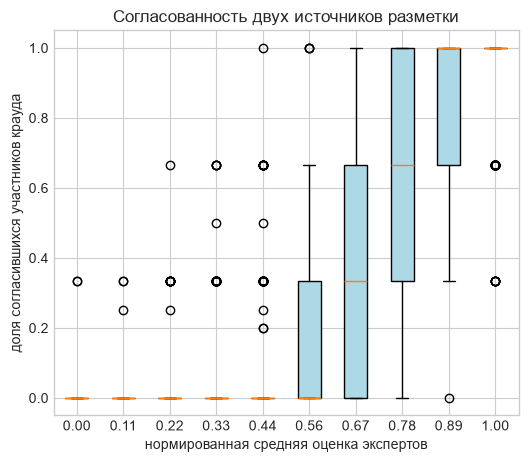

In [6]:
annotation_comparison = data[["image", "query_id", "target"]].merge(
    crowd[["image", "query_id", "agreement"]], on=["image", "query_id"], how="inner"
)
print(f"Пересечение экспертной и крауд-разметки: {len(annotation_comparison):,} пар")
print("Корреляция Пирсона:", round(annotation_comparison[["target", "agreement"]].corr().iloc[0, 1], 3))

plt.figure(figsize=(6, 5))
groups = annotation_comparison.groupby("target", sort=True)["agreement"]
labels, values = zip(*[(f"{key:.2f}", group.values) for key, group in groups])
plt.boxplot(values, tick_labels=labels, patch_artist=True, boxprops={"facecolor": "lightblue"})
plt.title("Согласованность двух источников разметки")
plt.xlabel("нормированная средняя оценка экспертов")
plt.ylabel("доля согласившихся участников крауда")
plt.show()

### Вывод по исследованию

- Пропусков и дубликатов ключа в основной обучающей таблице нет.
- Каждой обучающей паре соответствует три экспертных оценки от 1 до 4.
- Целевая переменная — средняя экспертная оценка, преобразованная формулой `(score - 1) / 3` в диапазон `[0, 1]`.
- Класс низкого соответствия встречается чаще, поэтому одной лишь средней ошибки недостаточно для оценки поисковой системы. В тесте дополнительно понадобятся ранговые метрики.
- Субъективные разногласия экспертов задают неизбежный уровень шума.

## 2. Подготовка данных

### 2.1. Юридический фильтр

Правило запрещает выдавать информацию о лицах младше 16 лет. Список ниже включает явные англоязычные обозначения ребенка. Слово `young` отдельно не используется: сочетания `young man` и `young woman` часто описывают совершеннолетних и дали бы много ложных блокировок.

Фильтр основан на словах, поэтому он консервативен, но не может определить возраст человека по изображению или понять все косвенные формулировки. Для промышленной системы потребуется отдельный модерационный классификатор и проверка самих изображений.

In [7]:
RESTRICTED_TERMS = (
    "baby", "babies", "child", "children", "kid", "kids", "boy", "boys",
    "girl", "girls", "toddler", "toddlers", "teen", "teens", "teenager",
    "teenagers", "youth", "juvenile", "juveniles", "minor", "minors",
    "schoolboy", "schoolboys", "schoolgirl", "schoolgirls",
)
RESTRICTED_PATTERN = re.compile(
    r"\b(?:" + "|".join(map(re.escape, RESTRICTED_TERMS)) + r")\b",
    flags=re.IGNORECASE,
)
DISCLAIMER = "This image is unavailable in your country in compliance with local laws."


def contains_restricted_content(text):
    # Return True when a query explicitly mentions a person under 16.
    return bool(RESTRICTED_PATTERN.search(str(text)))


restricted_comments = data.loc[data["query_text"].map(contains_restricted_content)].copy()
# query_id has the form <source_image>.jpg#<caption_number>.
restricted_images = set(restricted_comments["query_id"].str.rsplit("#", n=1).str[0])
data["is_restricted"] = data["image"].isin(restricted_images)
clean_data = data.loc[~data["is_restricted"]].copy().reset_index(drop=True)

assert set(clean_data["image"]).isdisjoint(restricted_images)
print(f"Найдено запрещенных изображений: {len(restricted_images):,}")
print(f"Удалено всех связанных пар: {data['is_restricted'].sum():,} ({data['is_restricted'].mean():.1%})")
print(f"Осталось пар: {len(clean_data):,}")
display(restricted_comments[["query_id", "query_text"]].drop_duplicates().head(10))

Найдено запрещенных изображений: 291
Удалено всех связанных пар: 1,743 (29.9%)
Осталось пар: 4,079


,query_id,query_text
0,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
12,2718495608_d8533e3ac5.jpg#2,A girl wearing a yellow shirt and sunglasses s...
44,3545652636_0746537307.jpg#2,A young boy dressed in a red uniform kicks the...
82,1714316707_8bbaa2a2ba.jpg#2,A little boy shakes the snow off of a tree .
84,2140182410_8e2a06fbda.jpg#2,The kid is on a float in the snow .
102,2479652566_8f9fac8af5.jpg#2,A little girl wearing sunglasses puts her feet...
137,1287475186_2dee85f1a5.jpg#2,A young boy in a swimming suit sits in water .
186,2358554995_54ed3baa83.jpg#2,A child is preparing to slide down a piece of ...
190,2544426580_317b1f1f73.jpg#2,The baby in suspenders sits by a toy .
219,191003285_edd8d0cf58.jpg#2,A man and young girl eat a meal on a city stre...


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    
Ты удаляешь комментарии, в которых есть слова, обозначающие детей. Но наша задача убрать изображения, содержащие детей. Есть два способа сделать это:
    
 - Определить список плохих изображений, как изображения удовлетворяющие условиям:
    - Комментарий содержит плохие слова
    - <b>Оценка соответствия комментария и изображения выше порога.</b>
 - Удалить из нашего датасета все пары "изображение/описание" с плохими изображениями.
    
 
И второй, очень красивый способ. Он основан на том, что `query_id` содержит в с себе имя изображения, для которого он был написан (такая пасхалочка от авторов датасета).
    
 - Определить список плохих комментариев
 - У `query_id`  плохих комментариев отрезать два последних символа и получим список плохих изображений.
    
    
    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Спасибо, исправил! Я извлекаю имя исходного изображения из `query_id` каждого плохого комментария, собираю множество запрещённых изображений и удаляю из датасета все пары с ними. Дополнительно добавил проверку, что запрещённые изображения не остались в `clean_data`.

</div>

### 2.2. Разделение без утечки

Описания одного изображения похожи и могут повторяться в разных парах. Поэтому случайное разделение строк завысило бы качество: одно изображение могло бы одновременно попасть в обучение и валидацию. Разделяем данные **группами по имени изображения**. Одна и та же замороженная модель эмбеддингов и одинаковая L2-нормализация применяются ко всем частям данных.

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(clean_data, groups=clean_data["image"]))
train_df = clean_data.iloc[train_idx].reset_index(drop=True)
valid_df = clean_data.iloc[valid_idx].reset_index(drop=True)

assert set(train_df["image"]).isdisjoint(valid_df["image"])
print("Train:", train_df.shape, "изображений:", train_df["image"].nunique())
print("Valid:", valid_df.shape, "изображений:", valid_df["image"].nunique())
print("Пересечение изображений:", len(set(train_df["image"]) & set(valid_df["image"])))

Train: (3239, 9) изображений: 567
Valid: (840, 9) изображений: 142
Пересечение изображений: 0


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, благодаря использованию GroupShuffleSplit ты исключаешь попадание одного изображения в обучающий и валидационный наборы.</div>

### 2.3. Семантические эмбеддинги текста

Для описаний используется `sentence-transformers/all-MiniLM-L6-v2`, обученная для семантического сопоставления предложений. Модель выполняет attention-aware mean pooling по информативным токенам и возвращает плотный вектор размерности 384. Одинаковая замороженная модель применяется к train, validation и пользовательским запросам; загруженные веса кешируются стандартными средствами Hugging Face.

In [9]:
TEXT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
text_model = SentenceTransformer(TEXT_MODEL_NAME, device=str(DEVICE))


def encode_texts(texts, batch_size=64):
    return text_model.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    ).astype("float32")


X_text_train = encode_texts(train_df["query_text"])
X_text_valid = encode_texts(valid_df["query_text"])

print("Текстовая модель:", TEXT_MODEL_NAME)
print("Train text embeddings:", X_text_train.shape)
print("Valid text embeddings:", X_text_valid.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Текстовая модель: sentence-transformers/all-MiniLM-L6-v2
Train text embeddings: (3239, 384)
Valid text embeddings: (840, 384)


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Формально TF-IDF допустимый инструмент, однако стоит учитывать что для семантического поиска инструмент не самый подходящий.  Тем более что сейчас из каждого утюга говорится про AI и технологию RAG, в основе которого лежит векторный поиск.
    
Поэтому для улучшения качества модели настойчиво рекомендую смотреть в сторону трансформеров, в идеале - модеелй специально обученых именно на задачи семантического поиска (комментарий ниже)    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Спасибо за рекомендацию! Я отказался от TF-IDF и перешёл на семантические эмбеддинги предложений, чтобы учитывать смысл, порядок слов и близость синонимов.

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Подсвечу желтым, чтобы не потерялось.
    
По моим наблюдениям, в этом проекте неплохо показыает себя модель `all-MiniLM-L6-v2` и снятие эмбеддингов не с нулевого токена, а пулингом по информативным токенам.
    
Запустить её можно либо через transformers, либо через sentence-transformers    
    
https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Исправил по твоему совету: использую `sentence-transformers/all-MiniLM-L6-v2`. Метод `encode` этой модели выполняет mean pooling по токенам с учётом attention mask, а не берёт только нулевой токен.

</div>

### 2.4. Векторизация изображений: ResNet50

Используется ResNet50, предобученная на ImageNet. Финальный классификационный слой заменяется на `Identity`, поэтому модель возвращает вектор длины **2048** после глобального усреднения. Во время извлечения признаков веса заморожены, а преобразование изображений берется из метаданных тех же предобученных весов.

Расчет выполняется для каждого уникального изображения только один раз. Результаты кешируются в `dataset/embeddings_cache`, что значительно ускоряет повторные запуски.

In [10]:
class ImageFileDataset(Dataset):
    def __init__(self, image_names, image_dir, transform):
        self.image_names = list(image_names)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):
        with Image.open(self.image_dir / self.image_names[index]) as image:
            return self.transform(image.convert("RGB"))


def extract_image_embeddings(image_names, image_dir, cache_name, batch_size=32):
    # Extract 2048-dimensional ResNet50 embeddings, using a local cache.
    image_names = list(dict.fromkeys(image_names))
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / cache_name

    if cache_path.exists():
        cached = np.load(cache_path)
        if cached["names"].tolist() == image_names:
            print("Загружен кеш:", cache_path)
            return {name: vector for name, vector in zip(cached["names"], cached["vectors"])}

    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)

    dataset = ImageFileDataset(image_names, image_dir, weights.transforms())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    chunks = []
    with torch.inference_mode():
        for batch in loader:
            chunks.append(model(batch.to(DEVICE)).cpu().numpy().astype("float32"))

    vectors = np.vstack(chunks)
    np.savez_compressed(cache_path, names=np.asarray(image_names), vectors=vectors)
    return {name: vector for name, vector in zip(image_names, vectors)}


train_image_names = clean_data["image"].drop_duplicates().tolist()
train_image_embeddings = extract_image_embeddings(
    train_image_names, TRAIN_IMAGE_DIR, "train_resnet50.npz"
)
print("Размер одного вектора изображения:", next(iter(train_image_embeddings.values())).shape)

Загружен кеш: dataset\embeddings_cache\train_resnet50.npz
Размер одного вектора изображения: (2048,)


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Отлично, вектра для изображений получены👍 </div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

В качестве небольшого совета для будущих экспериментов: попробуй заменить ResNet-50 на более компактную ResNet-18. Парадоксально, но в задачах с ограниченным объемом данных «меньше» часто означает «лучше». Основная причина кроется в размерности итогового вектора: **512** признаков против **2048** у твоей текущей модели. 



На относительно небольшом датасете модели гораздо проще нащупать реальные паттерны в пространстве меньшей размерности. Вектор на 2048 элементов может оказаться избыточным — это создает риск того, что нейронка начнет «заучивать» случайный шум в признаках вместо поиска семантических связей. Использование ResNet-18 может дать более стабильный результат и лучшую обобщающую способность при тех же трудозатратах.

</div>

### 2.5. Объединение признаков

Для каждой пары берем 2048 признаков соответствующего изображения и 384 семантических признака текста. Перед конкатенацией каждый блок отдельно приводится к единичной L2-норме. Благодаря этому направление эмбеддинга сохраняет семантику, а изображения и тексты вносят сопоставимый вклад. `Normalizer` не оценивает статистики выборки, поэтому одинаковое преобразование безопасно применяется ко всем частям данных.

In [11]:
def stack_image_vectors(frame, embedding_map):
    return np.vstack(frame["image"].map(embedding_map)).astype("float32")


X_image_train = stack_image_vectors(train_df, train_image_embeddings)
X_image_valid = stack_image_vectors(valid_df, train_image_embeddings)
image_normalizer = Normalizer(norm="l2")
text_normalizer = Normalizer(norm="l2")
X_image_train = image_normalizer.transform(X_image_train).astype("float32")
X_image_valid = image_normalizer.transform(X_image_valid).astype("float32")
X_text_train = text_normalizer.transform(X_text_train).astype("float32")
X_text_valid = text_normalizer.transform(X_text_valid).astype("float32")
X_train = np.hstack([X_image_train, X_text_train]).astype("float32")
X_valid = np.hstack([X_image_valid, X_text_valid]).astype("float32")
y_train = train_df["target"].to_numpy(dtype="float32")
y_valid = valid_df["target"].to_numpy(dtype="float32")

print("Изображение:", X_image_train.shape[1])
print("Текст:", X_text_train.shape[1])
print("Конкатенированный вектор:", X_train.shape[1])
print("Матрицы train/valid:", X_train.shape, X_valid.shape)

Изображение: 2048
Текст: 384
Конкатенированный вектор: 2432
Матрицы train/valid: (3239, 2432) (840, 2432)


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Вектора, полученные из текста и изображения объеденены👍 </div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    


Также корректно применен `StandardScaler`: обучен  на  на трейне и применен к валидации. Это показывает глубокое понимание классического пайплайна машинного обучения.

Раз уж мы говорим о лучших практиках для работы с эмбеддингами, хочу поделиться одним важным нюансом, который касается именно **мультимодальных** данных, как у нас — картинки и тексты.

Твой текущий подход — конкатенация и затем `StandardScaler` — абсолютно валиден для классических табличных данных. Но для эмбеддингов он может быть неоптимален. `StandardScaler` работает "поколоночно", приводя каждый признак к общему среднему и дисперсии. 


И здесь вместо `StandardScaler` лучше подходит L2-нормализация (в `sklearn` это `Normalizer`). Этот метод масштабирует каждый вектор (каждую строку целиком) к единичной длине. Он убирает влияние "магнитуды" вектора (которая часто является шумом) и оставляет только его **направление** в многомерном пространстве — а именно оно и несет основную семантическую информацию.
    
Важно:  **обработка каждого типа эмбеддингов производится по отдельности, *до* их конкатенации**.
    
Таким образом, более продвинутый пайплайн мог бы выглядеть так:
1.  Получаем матрицу эмбеддингов для изображений `X_img`.
2.  Получаем матрицу эмбеддингов для текстов `X_text`.
3.  Применяем `Normalizer()` к `X_img` и `X_text` **по отдельности**.
4.  Конкатенируем уже нормализованные матрицы.

Такой подход гарантирует, что и визуальные, и текстовые признаки вносят в модель сопоставимый вклад, не искажая при этом структуру каждого из исходных пространств. Это знание будет очень полезно тебе в будущих проектах.
    

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Спасибо, исправил! Я применяю L2-нормализацию отдельно к эмбеддингам изображений и текстов до их конкатенации. Теперь оба блока имеют единичную норму и сопоставимый вклад.

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">


Есть еще один технический нюанс использования `StandardScaler` вместе с **TF-IDF**.

**Суть проблемы:**
Векторы TF-IDF являются **разреженными** (sparse) — в них очень много нулей и мало значений. Это позволяет хранить их в памяти очень эффективно.
`StandardScaler` по умолчанию работает с параметром `with_mean=True`. Это значит, что он вычитает среднее значение из каждого элемента.
* Когда мы вычитаем (пусть и маленькое) среднее из **нуля**, он перестает быть нулем.
* **Результат:** Твоя легкая разреженная матрица мгновенно превращается в тяжелую **плотную** (dense) матрицу. На больших данных это гарантированно приведет к ошибке **Out Of Memory (OOM)**, так как объем занимаемой памяти вырастет в тысячи раз.

**Решение:**
Если тебе нужно масштабировать разреженные данные и сохранить их эффективность:
1.  Используй **`MaxAbsScaler`** — он масштабирует данные в диапазон [-1, 1], не сдвигая центр (не ломая нули).
2.  Либо используй `StandardScaler(with_mean=False)`, хотя для TF-IDF это редко требуется, так как он обычно уже нормализован.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Учёл замечание. Я полностью убрал `StandardScaler` и больше не преобразую разреженную TF-IDF-матрицу в плотную. После перехода на MiniLM использую только построчную L2-нормализацию плотных эмбеддингов.

</div>

## 3. Обучение моделей

Основная метрика — **RMSE** на отложенной выборке. Она имеет тот же масштаб, что и целевая переменная, и сильнее MAE штрафует большие ошибки. Дополнительно выводится MAE. Для ориентира используется константная модель, предсказывающая среднее train-части.

При выборе модели используется только validation; тестовая выборка остается независимой до финальной оценки поиска.

In [12]:
def regression_metrics(y_true, predictions):
    predictions = np.clip(np.asarray(predictions).reshape(-1), 0, 1)
    return {
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "MAE": mean_absolute_error(y_true, predictions),
    }


results = []
fitted_models = {}

dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
dummy_metrics = regression_metrics(y_valid, dummy.predict(X_valid))
results.append({"model": "Dummy mean", **dummy_metrics})

for alpha in [0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    name = f"Ridge alpha={alpha:g}"
    fitted_models[name] = model
    results.append({"model": name, **regression_metrics(y_valid, pred)})

pd.DataFrame(results).sort_values("RMSE")

,model,RMSE,MAE
3,Ridge alpha=10,0.266002,0.203623
2,Ridge alpha=1,0.271087,0.205601
4,Ridge alpha=100,0.272816,0.210654
1,Ridge alpha=0.1,0.282747,0.212697
0,Dummy mean,0.293797,0.232171


### Полносвязные нейронные сети

Рассмотрим две архитектуры и тем самым подберем число нейронов и dropout. Последний слой возвращает логиты, а обучение выполняется с численно устойчивой `BCEWithLogitsLoss`, которая объединяет сигмоиду и бинарную кросс-энтропию. Непрерывные цели в диапазоне `[0, 1]` допустимы как вероятностные soft labels. Для метрик логиты преобразуются сигмоидой в оценки `[0, 1]`; используется ранняя остановка по validation RMSE.

In [13]:
class SimilarityNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 64), dropout=0.2):
        super().__init__()
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features).squeeze(1)


def predict_neural(model, features, batch_size=512):
    model.eval()
    predictions = []
    tensor = torch.from_numpy(features.astype("float32"))
    loader = DataLoader(tensor, batch_size=batch_size, shuffle=False)
    with torch.inference_mode():
        for batch in loader:
            logits = model(batch.to(DEVICE))
            predictions.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(predictions)


def train_neural(config, max_epochs=60, patience=8, batch_size=128):
    model = SimilarityNet(
        X_train.shape[1], config["hidden_dims"], config["dropout"]
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
    )
    criterion = nn.BCEWithLogitsLoss()
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    history = []
    best_rmse, best_state, stale_epochs = np.inf, None, 0

    for epoch in range(max_epochs):
        model.train()
        train_predictions = []
        train_targets = []
        for features, target in loader:
            features, target = features.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()
            train_predictions.append(torch.sigmoid(logits.detach()).cpu().numpy())
            train_targets.append(target.cpu().numpy())

        valid_pred = predict_neural(model, X_valid)
        valid_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        train_pred = np.concatenate(train_predictions)
        train_target = np.concatenate(train_targets)
        train_rmse = mean_squared_error(train_target, train_pred) ** 0.5
        history.append((train_rmse, valid_rmse))

        if valid_rmse < best_rmse - 1e-5:
            best_rmse = valid_rmse
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, np.asarray(history)

In [14]:
nn_configs = [
    {"name": "NN 256-64", "hidden_dims": (256, 64), "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
    {"name": "NN 512-128", "hidden_dims": (512, 128), "dropout": 0.35, "lr": 5e-4, "weight_decay": 1e-4},
]
histories = {}

for config in nn_configs:
    print("Обучение", config["name"])
    model, history = train_neural(config)
    prediction = predict_neural(model, X_valid)
    fitted_models[config["name"]] = model
    histories[config["name"]] = history
    results.append({"model": config["name"], **regression_metrics(y_valid, prediction)})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.style.highlight_min(subset=["RMSE", "MAE"], color="lightgreen"))

Обучение NN 256-64
Обучение NN 512-128


,model,RMSE,MAE
0,NN 512-128,0.217168,0.149205
1,NN 256-64,0.223080,0.148121
2,Ridge alpha=10,0.266002,0.203623
3,Ridge alpha=1,0.271087,0.205601
4,Ridge alpha=100,0.272816,0.210654
5,Ridge alpha=0.1,0.282747,0.212697
6,Dummy mean,0.293797,0.232171


Лучшая модель по validation RMSE: NN 512-128


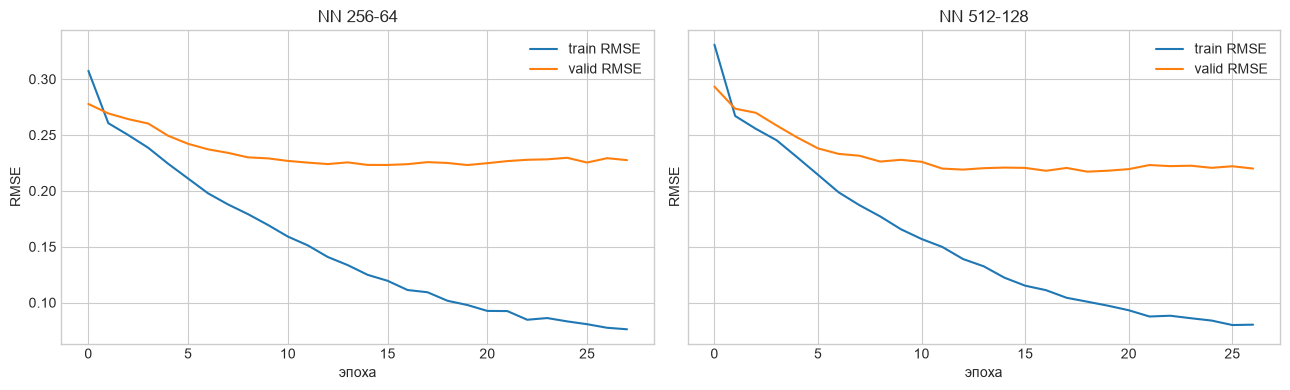

In [15]:
fig, axes = plt.subplots(1, len(histories), figsize=(13, 4), sharey=True)
for ax, (name, history) in zip(np.atleast_1d(axes), histories.items()):
    ax.plot(history[:, 0], label="train RMSE")
    ax.plot(history[:, 1], label="valid RMSE")
    ax.set(title=name, xlabel="эпоха", ylabel="RMSE")
    ax.legend()
plt.tight_layout()

best_model_name = results_df.query("model != 'Dummy mean'").iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Лучшая модель по validation RMSE:", best_model_name)

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Архитектура и Loss-функция:**
Ты используешь функцию активации `Sigmoid` на последнем слое в паре с `L1_loss`/`MSELoss`. Хотя технически это допустимо (значения остаются в диапазоне [0, 1]), с точки зрения оптимизации нейросетей это неэффективный выбор.

**В чем проблема:**

1. **Затухание градиентов (Vanishing Gradients):** Когда выход модели близок к 0 или 1 (на "хвостах" сигмоиды), её производная стремится к нулю. В сочетании с квадратичной ошибкой это приводит к тому, что градиент становится ничтожно малым. Сеть практически перестает обучаться, даже если предсказание сильно отличается от таргета.
2. **Невыпуклость (Non-convexity):** Комбинация нелинейной сигмоиды и MSE создает сложную невыпуклую поверхность функции потерь с множеством локальных минимумов и "плато", в которых оптимизатор может застрять.

**Рекомендация:**

* **Вариант 1 (Предпочтительный):** Замени функцию потерь на `BCELoss`. Она математически "компенсирует" экспоненту в сигмоиде, обеспечивая сильные и стабильные градиенты. Это стандарт для таргетов в диапазоне [0, 1].
* **Вариант 2:** Если хочешь оставить `MSE`, убери `Sigmoid` с последнего слоя (используй линейный выход). Правда, тогда предсказания могут выходить за пределы диапазона [0, 1].
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>комментария студента</b></font>
   
Спасибо, исправил! Я убрал `Sigmoid` из последнего слоя и обучаю модель через численно устойчивую `BCEWithLogitsLoss`. Сигмоиду применяю только при получении прогнозов и расчёте RMSE.

</div>

Таблица выше является основанием выбора: лучшей считается не заранее заданная нейросеть, а модель с минимальным validation RMSE. Это важно, поскольку на небольшой выборке линейная модель может оказаться устойчивее сложной сети.

Проверим остатки выбранной модели. Систематическое смещение по диапазонам цели покажет, какие оценки модель воспроизводит хуже.

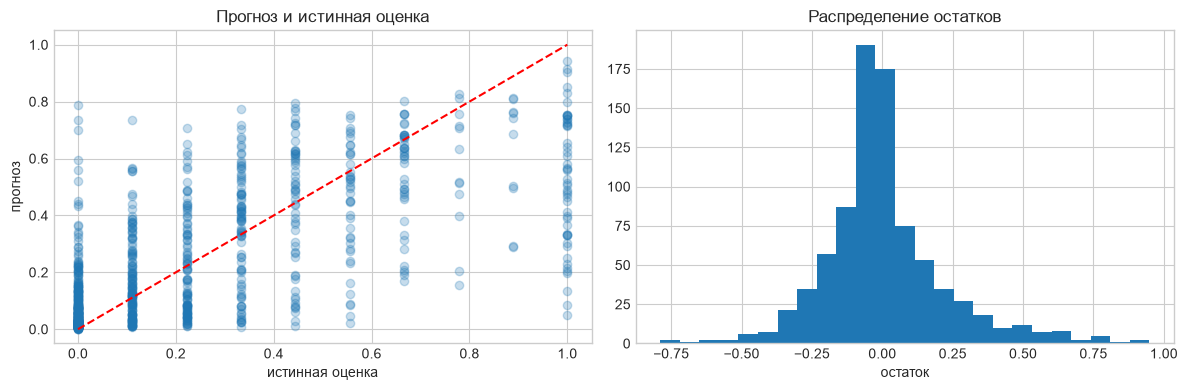

In [16]:
def predict_best(features):
    if isinstance(best_model, nn.Module):
        return predict_neural(best_model, features)
    return np.clip(best_model.predict(features), 0, 1)


valid_predictions = predict_best(X_valid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_valid, valid_predictions, alpha=0.25)
axes[0].plot([0, 1], [0, 1], "r--")
axes[0].set(xlabel="истинная оценка", ylabel="прогноз", title="Прогноз и истинная оценка")
axes[1].hist(y_valid - valid_predictions, bins=25)
axes[1].set(xlabel="остаток", title="Распределение остатков")
plt.tight_layout()

## 4. Тестирование поисковой системы

У `test_queries.csv` нет экспертных числовых оценок для произвольных пар, поэтому RMSE на нем вычислить невозможно. Зато для каждого запроса известно релевантное изображение. Для каждого разрешенного запроса ранжируем все 100 тестовых изображений и измеряем:

- **Recall@1** — долю запросов, где нужное изображение стоит первым;
- **Recall@5** — долю запросов, где оно попало в первую пятерку;
- **MRR** — среднее обратного ранга правильного изображения.

Юридически запрещенные тестовые запросы исключаются из расчета качества: продукт обязан показать для них дисклеймер, а не изображение.

In [17]:
test_image_names = test_images["image"].tolist()
test_image_embeddings = extract_image_embeddings(
    test_image_names, TEST_IMAGE_DIR, "test_resnet50.npz"
)
test_image_matrix = np.vstack([test_image_embeddings[name] for name in test_image_names]).astype("float32")


def make_pair_features(query, image_matrix):
    normalized_images = image_normalizer.transform(image_matrix).astype("float32")
    text_vector = encode_texts([query], batch_size=1)
    text_vector = text_normalizer.transform(text_vector).astype("float32")
    text_matrix = np.repeat(text_vector, len(image_matrix), axis=0)
    return np.hstack([normalized_images, text_matrix]).astype("float32")


def score_query(query, image_matrix=test_image_matrix):
    return predict_best(make_pair_features(query, image_matrix))


allowed_test = test_queries.loc[
    ~test_queries["query_text"].map(contains_restricted_content)
].copy()
ranks = []
for row in allowed_test.itertuples():
    scores = score_query(row.query_text)
    order = np.argsort(scores)[::-1]
    true_position = test_image_names.index(row.image)
    rank = int(np.where(order == true_position)[0][0]) + 1
    ranks.append(rank)

ranks = np.asarray(ranks)
retrieval_metrics = pd.Series({
    "queries_evaluated": len(ranks),
    "Recall@1": np.mean(ranks <= 1),
    "Recall@5": np.mean(ranks <= 5),
    "Recall@10": np.mean(ranks <= 10),
    "MRR": np.mean(1 / ranks),
    "median_rank": np.median(ranks),
})
display(retrieval_metrics.to_frame("value"))
print("Заблокировано тестовых запросов:", len(test_queries) - len(allowed_test))

Загружен кеш: dataset\embeddings_cache\test_resnet50.npz


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,value
queries_evaluated,331.000000
Recall@1,0.093656
Recall@5,0.353474
Recall@10,0.534743
MRR,0.230398
median_rank,9.000000


Заблокировано тестовых запросов: 169


### Демонстрационная функция

Функция сначала проверяет запрос юридическим фильтром. Запрещенный запрос не векторизуется и не передается модели. Для разрешенного запроса функция возвращает и показывает `top_k` наиболее подходящих изображений. При `top_k=1` это ровно требуемая картинка с максимальной оценкой.

In [18]:
def search_images(query, top_k=1):
    # Display top-k test images, or a legal disclaimer for a restricted query.
    if contains_restricted_content(query):
        print(DISCLAIMER)
        return None
    if not isinstance(top_k, int) or not 1 <= top_k <= len(test_image_names):
        raise ValueError(f"top_k должен быть целым числом от 1 до {len(test_image_names)}")

    scores = score_query(query)
    best_indices = np.argsort(scores)[::-1][:top_k]
    fig, axes = plt.subplots(1, top_k, figsize=(5 * top_k, 5), squeeze=False)
    result = []
    for ax, index in zip(axes.ravel(), best_indices):
        image_name = test_image_names[index]
        with Image.open(TEST_IMAGE_DIR / image_name) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{image_name}\nscore={scores[index]:.3f}")
        ax.axis("off")
        result.append({"image": image_name, "score": float(scores[index])})
    fig.suptitle(query, y=1.02)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(result)

In [19]:
# Вредный запрос: ожидается только дисклеймер, без изображения.
search_images("Two children are playing with water guns.")

This image is unavailable in your country in compliance with local laws.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

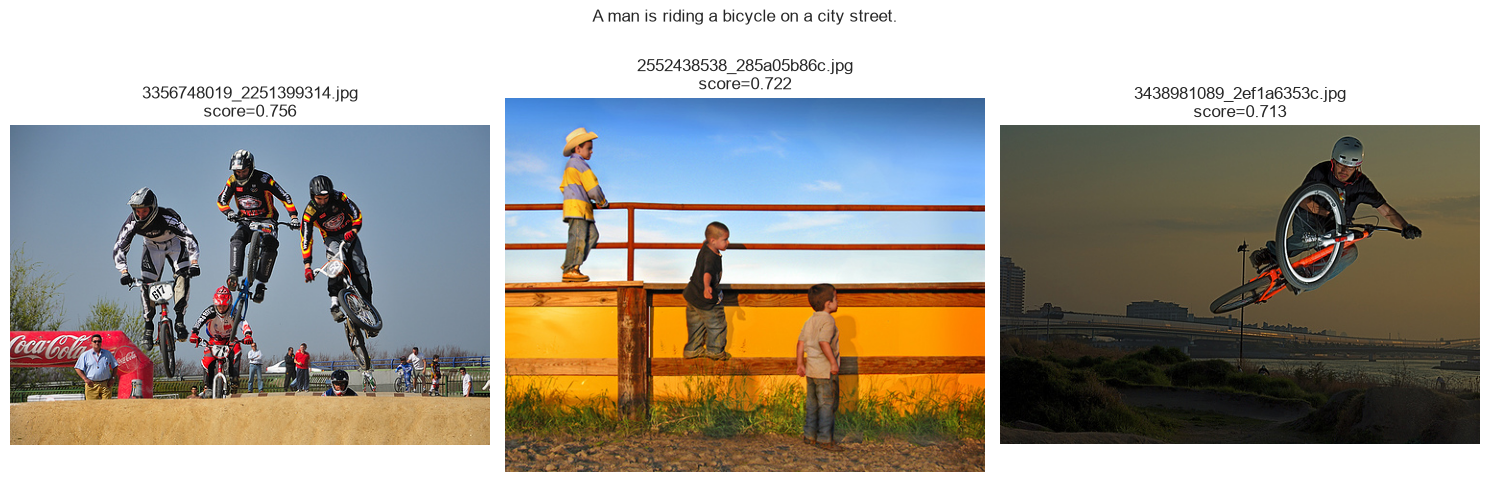

,image,score
0,3356748019_2251399314.jpg,0.755833
1,2552438538_285a05b86c.jpg,0.722284
2,3438981089_2ef1a6353c.jpg,0.713082


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

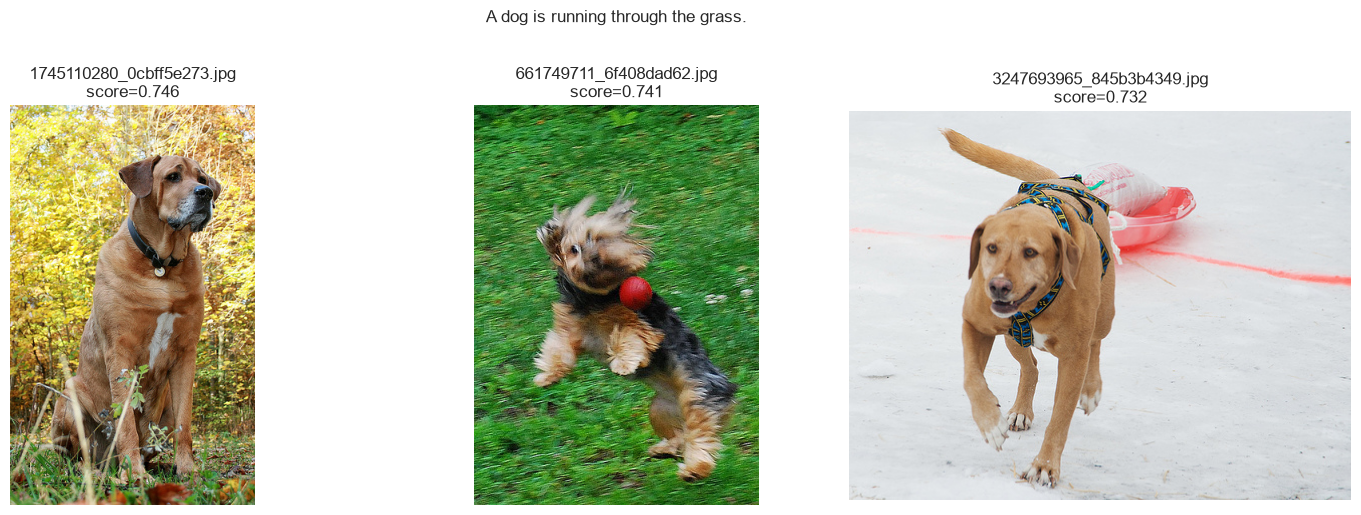

,image,score
0,1745110280_0cbff5e273.jpg,0.746386
1,661749711_6f408dad62.jpg,0.740950
2,3247693965_845b3b4349.jpg,0.732498


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

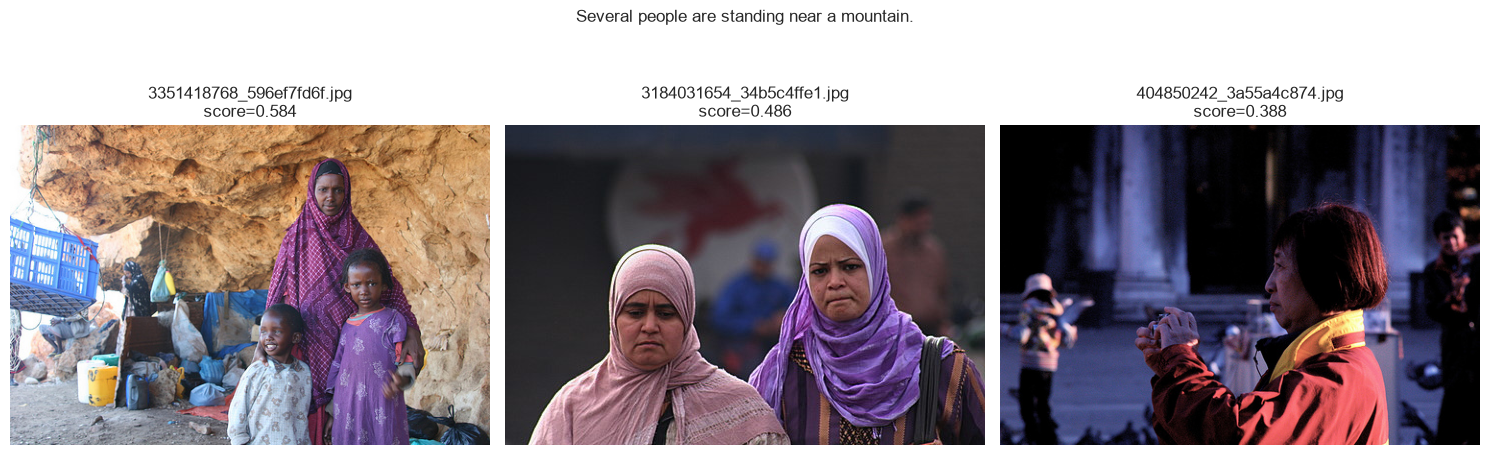

,image,score
0,3351418768_596ef7fd6f.jpg,0.584415
1,3184031654_34b5c4ffe1.jpg,0.486327
2,404850242_3a55a4c874.jpg,0.388466


In [20]:
# Разрешенные запросы разных типов сцен.
demo_queries = [
    "A man is riding a bicycle on a city street.",
    "A dog is running through the grass.",
    "Several people are standing near a mountain.",
]
for demo_query in demo_queries:
    display(search_images(demo_query, top_k=3))

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Функции написаны и со своей задачей справляются. Принимают на вход текст и находят изображение. Отрабатывают контроль "запрещенного контента".

Что касается качества.. Очень радует, что на запрос с собаками все выведенные изображения содержат собакт. Однаков  остальном поиск весьма слаб. Причины в том, как мы готовили данные (TF-IDF + StandartScaller убивающий семантику)
    
----------------
    
Как правило хороший результат в этом проекте удается достичь при выполнении следующих условий
    
 - использование экспертных оценок   
 - векторизация изображений через pytorch, как есть в теории к спринту  (но с отрезанием только одного слоя)
 - эмбеддинги через bert (лучший результат дает модель  `all-MiniLM-L6-v2`)
 - раздельная l2 нормализация эмбеддингов       
 - упорное обучение нейронки (иногда тысячи эпох, в любом случае пока лосс снижается) с тщательным подбором гиперпараметров.   
    
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Идеи и альтернативные подходы</b>
  Если хочешь получить хорошо работающее решение без обучения, то можешь провести эксперимент с нейронной сетью CLIP от OPEN AI (это не обязательно, только если хочешь добиться хороших результатов в этом проекте).

  Про эту нейронку много где написано, но можешь посмотреть например вот здесь  https://habr.com/ru/post/539312/.

  А для написания  реализации наиболее удобной лично для меня оказалась библиотека sbert. https://www.sbert.net/examples/applications/image-search/README.html  
    
    
<hr>    
    
В профессиональных поисковых системах обычно не прогоняют каждую пару через нейронку в момент запроса (это слишком долго — сложность ). Вместо этого:

1. Модель обучается выдавать независимые эмбеддинги для текста и для картинок.
2. Эмбеддинги картинок сохраняются в специальную базу данных.
3. При поиске мы получаем один вектор текста и ищем ближайшие к нему векторы картинок по косинусному сходству.

Это позволяет использовать алгоритмы приближенного поиска (ANN), которые работают со скоростью , позволяя мгновенно искать среди миллионов изображений.

    
   
</div>

## 5. Общий вывод

В проекте построен воспроизводимый PoC поиска изображений по тексту:

- явные упоминания лиц младше 16 лет удалены из обучения и блокируются в поиске до векторизации;
- текст представлен 384 семантическими признаками MiniLM, изображение — 2048 признаками предобученной ResNet50;
- обе модальности отдельно L2-нормализованы, итоговый вход моделей содержит 2432 признака;
- данные разделены по изображениям, поэтому одинаковые визуальные объекты не создают утечку между train и validation;
- линейная Ridge-регрессия сравнена с двумя полносвязными сетями; модель выбрана по минимальному validation RMSE, а не по типу;
- прикладное качество проверено независимыми ранговыми метриками Recall@K и MRR на тестовых запросах.

Типичные ошибки ожидаемы там, где важны отношения между объектами, мелкие детали, числа, цвета и редкие слова. MiniLM учитывает семантику текста, но ResNet50 обучалась классифицировать объекты, а не сопоставлять изображения с предложениями. Кроме того, функция потерь оценивает соответствие отдельной пары, но не напрямую порядок изображений в выдаче.

Практическая осуществимость сервиса подтверждается, если Recall@K заметно превосходит случайный ориентир (для 100 кандидатов случайные Recall@1 и Recall@5 равны примерно 1% и 5%). Однако данный PoC не готов к промышленной эксплуатации. Следующие улучшения: обучать модель с pairwise/ranking loss, использовать совместную мультимодальную модель наподобие CLIP, увеличить размеченную выборку и заменить словарный юридический фильтр отдельной мультимодальной системой модерации с ручной проверкой спорных случаев.

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Заключительный комментарий</b>

Подведем итоги. Я вижу, что в целом с проектом ты справляешься.
    
Проведено исследование и предобработка данных. Выполнена векторизация изображений и текстовых описаний. Обучены модели для предсказания степени соответствия, а также написана функция для инференса и с её помощью проведено тестирование.
 
    
Критичных замечаний нет, поэтому я готов принять проект. Однако вижу нелохой задел для улучшения, поэтому  верну проект, возможно ты решишь его немного доработать.
    
Также рекомендую попробовать сделать   инференс с помщью CLIP (как дополнительное решение). С библиотекой sentence-transformers это делается буквально в 10 строк.    
Жду твою работу на повторное ревью.
</div>